# Vehicle Classification Using Custom CNN

# Import Important Library


In [ ]:
# Standard Library for data
import numpy as np
import pandas as pd 
import os
import shutil
import zipfile
from pathlib import Path 
import cv2
from PIL import Image
import random

# keras
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
import numpy as np
import tensorflow as tf

# clasi report
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

# Prepare The Datasets and Augmentation

In [2]:
# ekstrak zip
def extract_zip(zip_path,extract_to="."):
    print(f"Mengekstrak {zip_path}")
    with zipfile.ZipFile(zip_path,"r") as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraksi Selesai\n")

# split the dataset
def split_dataset(source_dir,output_dir,train_ratio=0.7,val_ratio=0.15,test_ration=0.15,seed=42):
    random.seed(seed)
    
    source_path = Path(source_dir)
    output_path = Path(output_dir)
    
    for split in ["train","val","test"]:
        for class_dir in source_path.iterdir():
            if class_dir.is_dir():
                (output_path/split/class_dir.name).mkdir(parents=True,exist_ok=True)
    
    for class_dir in source_path.iterdir():
        if not class_dir.is_dir():
            continue
        
        class_name = class_dir.name
        images = [f for f in class_dir.iterdir() if f.suffix.lower() in [".jpg",".jpeg",".png"]]
        random.shuffle(images)
        
        total = len(images)
        train_end = int(total*train_ratio)
        val_end = train_end + int(total*val_ratio)
        
        splits = {
            "train" : images[:train_end],
            "val" : images[train_end:val_end],
            "test" : images[val_end:]
        }
        
        for split_name,split_images in splits.items():
            for img_path in split_images:
                dest = output_path/split_name/class_name/img_path.name
                shutil.copy2(img_path,dest)
                
        print(f"[{class_name}] Total: {total} → Train: {len(splits['train'])}, Val: {len(splits['val'])}, Test: {len(splits['test'])}")

In [3]:
# specified the destinec file
ZIPFILE = "archive.zip"
SOURCE = "Vehicles"
DEST = "ImageClasiDataset"

# apply the extraction
extract_zip(ZIPFILE,extract_to=".")
split_dataset(SOURCE,DEST)

Mengekstrak archive.zip
Extraksi Selesai

[Auto Rickshaws] Total: 800 → Train: 560, Val: 120, Test: 120
[Bikes] Total: 800 → Train: 560, Val: 120, Test: 120
[Cars] Total: 790 → Train: 553, Val: 118, Test: 119
[Motorcycles] Total: 800 → Train: 560, Val: 120, Test: 120
[Planes] Total: 797 → Train: 557, Val: 119, Test: 121
[Ships] Total: 800 → Train: 560, Val: 120, Test: 120
[Trains] Total: 800 → Train: 560, Val: 120, Test: 120


In [4]:
# function to safe the image into X and y
def load_dataset(folder: Path, split: str, img_size=(224, 224)):
    X = []
    y = []

    split_path = Path(folder) / split

    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name 

        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue

            img = Image.open(img_path).convert('RGB')   
            img = img.resize(img_size)                  
            X.append(np.array(img))                     
            y.append(class_name)                 

    return np.array(X), np.array(y)

In [112]:
# Apply the function
X_Train,Y_Train = load_dataset(DEST,"train")
X_Val,Y_Val = load_dataset(DEST,"val")
X_Test,Y_Test = load_dataset(DEST,"test")

In [113]:
print(f"panjang data training: {len(X_Train)}")
print(f"panjang data Validation: {len(X_Val)}")
print(f"panjang data Testing: {len(X_Test)}")


panjang data training: 3910
panjang data Validation: 837
panjang data Testing: 840


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

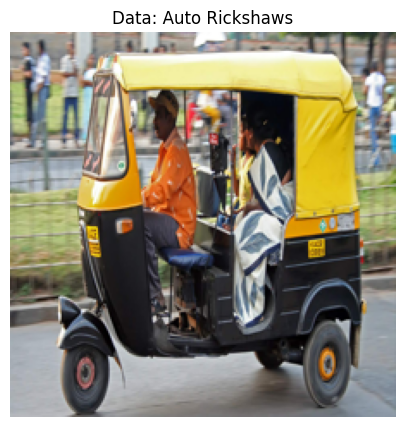

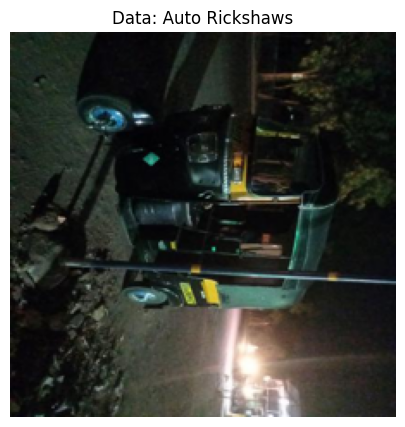

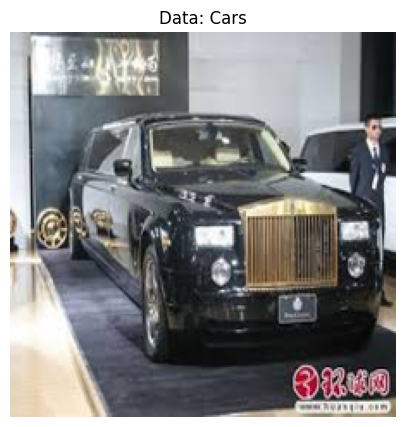

In [114]:
# see some data
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.title(f"Data: {Y_Train[0]}")
plt.imshow(X_Train[0])
plt.axis("off")

plt.figure(figsize=(10,5))
plt.title(f"Data: {Y_Train[1]}")
plt.imshow(X_Train[1])
plt.axis("off")

plt.figure(figsize=(10,5))
plt.title(f"Data: {Y_Train[1200]}")
plt.imshow(X_Train[1200])
plt.axis("off")


In [115]:
# Layer Augmentasi
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.001),
    tf.keras.layers.RandomContrast(0.001)
],name="data_augmentation")

# create tf dataset
def to_tf_dataset(X,y,class_names,batch_size=32,shuffle=False,augment=False):
    # Encoder label String to Integer
    label_encoder = {name:idx for idx,name in enumerate(class_names)}
    y_encoded = np.array([label_encoder[label] for label in y])
    
    # normalize the image
    X_normalized = X.astype("float32")/255.0
    
    ds = tf.data.Dataset.from_tensor_slices((X_normalized,y_encoded))
    
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))
        
    ds = ds.batch(batch_size)
    
    if augment:
        ds = ds.map(
            lambda x,y : (tf.clip_by_value(data_augmentation(x,training=True),0.0,1.0),y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    
    ds = ds.prefetch(tf.data.AUTOTUNE)
    
    return ds

# Daftar kelas
class_name = sorted([d.name for d in (Path(DEST)/"train").iterdir() if d.is_dir()])
print("Classes: ", class_name)

Classes:  ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


In [116]:
# membuat tensorflow dataset
train_ds = to_tf_dataset(X_Train,Y_Train,class_name,batch_size=32,shuffle=True,augment=True)
val_ds   = to_tf_dataset(X_Val,   Y_Val,   class_name, batch_size=32)
test_ds  = to_tf_dataset(X_Test,  Y_Test,  class_name, batch_size=32)

In [117]:
# cek bentuknya
for image,label in train_ds.take(1):
    print(f"Batch images shape : {image.shape}")
    print(f"Batch labels shape : {label.shape}") 

Batch images shape : (32, 224, 224, 3)
Batch labels shape : (32,)


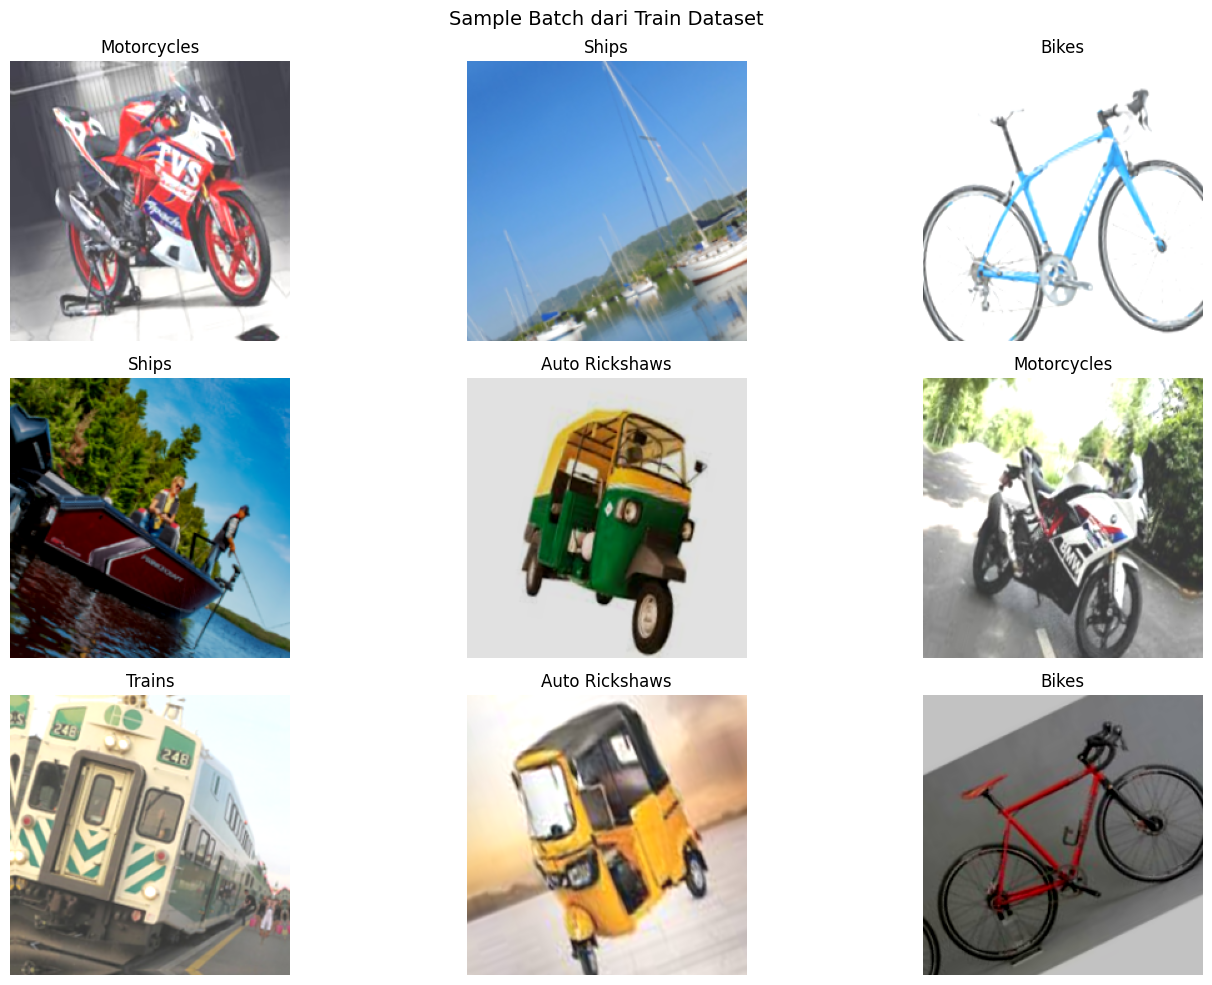

In [118]:
# Lihat beberapa gambar dari batch
for images, labels in train_ds.take(1):
    plt.figure(figsize=(15, 10))
    
    for i in range(min(9, len(images))):  # tampilkan max 9 gambar
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())     # .numpy() untuk convert tensor → array
        plt.title(class_name[labels[i].numpy()])
        plt.axis('off')
    
    plt.suptitle("Sample Batch dari Train Dataset", fontsize=14)
    plt.tight_layout()
    plt.show()

# Create The Model


In [ ]:
def build_model(input_shape = (224,224,3),num_classes=len(class_name)):
    model  = Sequential(name="vehicle_cnn")
    model.add(tf.keras.layers.Input(input_shape))

    model.add(tf.keras.layers.Conv2D(filters = 8 , kernel_size = (3,3) , padding = "same" , 
                    activation = "relu"))
    model.add(tf.keras.layers.MaxPooling2D(pool_size = (2,2)))

    model.add(tf.keras.layers.Conv2D(filters = 16, kernel_size = (3,3) , padding = "same" , 
                activation = "relu" ))
    model.add(tf.keras.layers.MaxPooling2D(pool_size = (2,2)))
    model.add(tf.keras.layers.Flatten())
    model.add(Dense(128 , activation = "relu"))
    model.add(Dense(128 , activation = "relu"))
    model.add(Dense(64 , activation = "relu"))
    model.add(Dense(7 , activation = "softmax"))
    
    return model

model3 = build_model()
model3.summary()    

Model: "vehicle_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 224, 224, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 112, 112, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,449,271 (24.60 MB)

 Trainable params: 6,449,271 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

In [137]:
# compile the model
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [138]:
# setting callbacknya
callbacks = [
    # Stop training jika val_loss tidak membaik setelah 5 epoch
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,  # kembalikan bobot terbaik otomatis
        verbose=1
    ),
    
    # Simpan model terbaik
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
    # Kurangi learning rate jika val_loss stagnan
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,        # lr = lr * 0.5
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [140]:
history = model3.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    callbacks = callbacks
)

Epoch 1/30


ValueError: 'Vehicles CNN_Vehicles CNN_vehicle_cnn_conv2d_28_kernel_momentum' is not a valid scope name. A scope name has to match the following pattern: ^[A-Za-z0-9_.\\/>-]*$

In [ ]:
y_pred_prob = model.predict(test_ds)               # semua prediksi sekaligus
y_pred_all  = np.argmax(y_pred_prob, axis=1)       # ambil index kelas tertinggi

# Ambil label asli dari test_ds
y_true_all = np.concatenate([y for _, y in test_ds], axis=0)

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step


In [ ]:
print(classification_report(y_true_all,y_pred_all))

              precision    recall  f1-score   support

           0       0.67      0.75      0.71       120
           1       0.65      0.92      0.76       120
           2       0.62      0.61      0.61       119
           3       0.63      0.70      0.66       120
           4       0.91      0.88      0.90       121
           5       0.87      0.80      0.83       120
           6       0.92      0.46      0.61       120

    accuracy                           0.73       840
   macro avg       0.75      0.73      0.73       840
weighted avg       0.75      0.73      0.73       840

